
Before we construct the proper RAW model, we need to remember that typcially subcarrier spacings are **15kHz for LTE, 30/60kHz for Higher-Throughput and 60/120kHz for mmWave**, the decisive factor is bandwidth since it combines:
$$\text{Bandwidth} = \text{fft\_size} \times \text{subcarrier\_spacing}$$


There are 12 subcarriers in each PRB (Physical Resource Block), and 14 OFDM symbols in each  slot, and it is not related to `resourcegrid()` object that we need to utilize in our model


The research model we are trying to build is a basic Detnet with full Sionna PHY chain (OFDM, 5G LDPC, CDL channel Estimation and Equalization),
**Talker ---->hop1--->Relay (Base Station)--->hop2-->Listener**

Each hop is an independent OFDM link, that will be assigned with resource grid, CDL channel, encoder and decoder, and relay decodes hop 1, and only if it
decodes successully once it re-encode and forard to hop2, acting as a **DetNet's store and foward semantics.**

Since we utilize PHY layer, the deterministic schedular reserves fixed 2-slot cycle (slot 0 is Talker==>Relay, slot 1 is Relay==>Listener), this is the baseline of DetNet-style scheduling.

We will add redundancy and replication in the later stage

The simulation environment relies on *Sionna 2.0.1*


In [1]:
import numpy as np
#Not sure we still need pytorch, but keep this thing in mind
import torch
from sionna.phy import Block
from sionna.phy.mapping import BinarySource, Mapper, Demapper
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers
from sionna.phy.mimo import StreamManagement
from sionna.phy.channel.tr38901 import CDL, Antenna
from sionna.phy.channel import OFDMChannel
from sionna.phy.utils import ebnodb2no, compute_ber



Global Initiate Configuration: We are using 5G NR parameters here

In [2]:
CARRIER_FREQUENCY = 3.5e9 #Hz
SUBCARRIER_SPACING = 30e3 #Hz
FFT_SIZE = 76 #subcarriers
NUM_OFDM_SYMBOLS = 14 #One slot for OFDM symbols
NUM_BITS_PER_SYMBOL = 2 #QPSK
CODERATE = 0.5 #Not all part of symbol is information bits
CDL_MODEL = "C" #Mderate Delay Mode
DELAY_SPREAD = 100e-9 #s
UE_SPEED = 60.0 #m/s, cars
BATCH_SIZE = 64
EBN0_DB = 8.0 #Per-hop SNR, we can testify various options

RESOURCE_GRID=ResourceGrid(
    num_ofdm_symbols=NUM_OFDM_SYMBOLS,
    fft_size=FFT_SIZE,
    subcarrier_spacing=SUBCARRIER_SPACING,
    num_tx=1,
    num_streams_per_tx=1,
    cyclic_prefix_length=6,
    pilot_pattern="kronecker",
    pilot_ofdm_symbol_indices=[2,11],
    
)

STREAM_MANAGEMENT = StreamManagement (np.array([[1]]),1)

N_CODED = int (RESOURCE_GRID.num_data_symbols * NUM_BITS_PER_SYMBOL)
K_INFO = int (N_CODED * CODERATE)


print (f"Information bits {K_INFO}, {N_CODED} coded bits per PDU")




Information bits 912, 1824 coded bits per PDU


Now, we start building *PHY Link* with one OFDM Hop

The workflow is: `Bits-->LDPC-->QAM-->OFDM ResourceGird-->CDL Channel-->LS Channel Estimation-->LMMSE Equalization-->Demap-->LDPC Decode`
In general, this is one single DetNet hop (Talker-->Relay or Relay-->Listener)

In [3]:
class PHYLINK (Block):
    def __init__(self, name, ebno_db=EBN0_DB):
        super().__init__()
        self.name=name
        self.ebno_db=ebno_db


        self.binary_source = BinarySource()
        self.encoder = LDPC5GEncoder(K_INFO, N_CODED)
        self.mapper = Mapper("qam", NUM_BITS_PER_SYMBOL)
        self.rg_mapper = ResourceGridMapper (RESOURCE_GRID)


        tx_antenna = Antenna(polarization="single",
                             polarization_type ="V",
                             antenna_pattern="38.901",
                             carrier_frequency=CARRIER_FREQUENCY)

        rx_antenna = Antenna(polarization="single",
                             polarization_type="V",
                            antenna_pattern="38.901",
                            carrier_frequency=CARRIER_FREQUENCY)

        self.cdl = CDL(model=CDL_MODEL,
                      delay_spread=DELAY_SPREAD,
                      carrier_frequency=CARRIER_FREQUENCY,
                      ut_array=rx_antenna,
                      bs_array=tx_antenna,
                      direction="uplink",
                      min_speed=UE_SPEED,
                      max_speed=UE_SPEED, #Tunable Parameter
                      )
        self.channel = OFDMChannel(self.cdl,
                                   RESOURCE_GRID,
                                   add_awgn=True,
                                   normalize_channel=True,
                                   return_channel=False,
            
        )

        self.ls_set = LSChannelEstimator(RESOURCE_GRID,interpolation_type="nn")
        self.lmmse_equ = LMMSEEqualizer(RESOURCE_GRID, STREAM_MANAGEMENT)
        self.demapper = Demapper("app","qam",NUM_BITS_PER_SYMBOL)
        self.decoder = LDPC5GDecoder(self.encoder, num_iter=20)



    def call(self, batch_size, tx_bits=None):    
            """
            Runs one PDU batch cross this hop.

            If there is no tx_bits, the function generates the fresh payload,
            else, the information bitsa are transmitted

            Return per_pdu_success is a boolean numpy vector of shape [batch_size]
            indicating the scheduler that PDUs crosss this hop successfully

            """

            if tx_bits is None:
                tx_bits = self.binary_source ([batch_size, 1,1,K_INFO])

            codewords = self.encoder(tx_bits)
            symbols = self.mapper(codewords)
            x_rg = self.rg_mapper(symbols)

            no = ebnodb2no(self.ebno_db, NUM_BITS_PER_SYMBOL,CODERATE, RESOURCE_GRID)
            y = self.channel (x_rg, no)

            h_hat, err_var = self.ls_set(y,no)
            x_hat, no_eff = self.lmmse_equ(y, h_hat, err_var, no)
        
            #We add a real-time link quality proxy, it works before decoding process
            # a real reciever know  this from channel estimation/equalization well before it knows whether PDU
            # will be decoded correctly, higher no_eff represents the worse link, and this is the TRIGGER for PLR
            #react within the SAME cycle instead of next one.

            #Low no_eff means the symbol is trustworthy and high value is the sign of noisy and reliable.


            self.last_no_eff = float(no_eff.mean().detach().cpu().item())
            #Mean compresses the tesnor into 0-dimension
            #Detach strips the gradient-tracking machinery off to avoid memory waste
            #cpu because python native float lives in CPU and we need to copy the original one from GPU
            #item extract that single value from tensor object to have a plain python scalar
            #self.last_no_eff stored the value so other part can see how noisy was channel for hop 1a on the recent call
            





        
            llr = self.demapper(x_hat, no_eff)
            decoded_bits = self.decoder(llr)

            #Per-PDU success: perfect match between sent and decoded inrfo bits
            #A CRC check on a real DetNet PDU


            matches=torch.all(
                torch.eq(tx_bits.to(torch.int32),decoded_bits.to(torch.int32)),
                dim = -1,
            )

            success = matches.reshape(-1).cpu().numpy()

            return tx_bits, decoded_bits, success

        

#CDL (Clustered Delay Line Channel Model) gives a realistic standardized multipath fading channel, so the link is experiencing some interference more than AWGN

#LS Estimator (Least Squares Channel Estimation) allows the receiver to estimated channel before equalization based on known pilot symbols to have reliable DetNet Link

#LMMSE Equalizer removies the distortion the channel has from the interfenece and fading, and receiver can recover symbol.

#CDL (creates a realistic, imperfect channel) 
#→ LS (estimates that unknown channel from pilots) 
#→ LMMSE (uses the estimate to undo channel distortion) 
#→ clean symbols → decoder → reliable bits.

        
        
        

**Measured Latency**
Although the latency in this stage remains identical since we do not addd any flunctuational factors to the transmitted PDU yet, but we utilize depature/arrival timestamps with a simulated clock to compute the realistic latency to build an evaluation based for a complex system later on.

We add timestamp to each PDU with a real depature time (leave the Talker) and arrival time (it is decoded at the listener), and compute the **latency as the difference of those two timestamps**, `SimClock` advances in real seconds, utilzing the actual OFDM slot duration derived from `OFDM Resource Grid` not from Python wall-clock since it refelects on hardware and overhead instead of physical link

The output latency should be identical in this version of development since we add one path with same initial PDU



In [4]:
class SimClock:
    """
    Tracking simulated elapsed time in real seconds, advancing by the
    actual OFDM slots duration each time a slot is consumed. The PDU depature
    and arrival times and measure latency as a real difference, the clock
    is continuously crossing the cycles not reset, therefore, it should reflect
    a single ongoing PDU timeline
    """
    def __init__(self, slot_duration_s):
        self.slot_duration_s=slot_duration_s
        self.t=0.0

    def now(self):
        return self.t
        
    def advance_slot(self):
        self.t += self.slot_duration_s
        return self.t


    #The slot duration is from OFDM numerology in Resource_Grid()
    #with cyclic prefix with same topology/channel
    #The measurement is implemented instead of asssumption



ofdm_symbol_duration = RESOURCE_GRID.ofdm_symbol_duration #seconds with CP
slot_duration_s=NUM_OFDM_SYMBOLS * ofdm_symbol_duration

print(f"OFDM Symbol Duration with Cyclic Prefix: {ofdm_symbol_duration*1e6:.3f} us")
print(f"Slot Duration: {slot_duration_s*1e6:.3f} us")
    
        

    

    

OFDM Symbol Duration with Cyclic Prefix: 35.965 us
Slot Duration: 503.509 us


**DetNet Scheduler: Fixed 2-Slot Cycle**

-slot 0: Talker-->Relay (Hop1)
-slot 1: Relay-->Listener (Hop2)

Calling `run_cycle()` each time to simulate one fixed-length cycyle for a batch of PDUs precisely, and to report if each PDU reaches to listener within the bouded latency (2 slots) or gets dropped


In [5]:
class DetNetScheduler:

    def __init__(self, batch_size=BATCH_SIZE, clock =None):
        self.batch_size = batch_size
        self.hop1 = PHYLINK ("Talker->Relay")
        self.hop2 = PHYLINK ("Relay->Listener")
        self.clock=clock if clock is not None else SimClock(slot_duration_s)

    def run_cycle(self):

        depature_time=self.clock.now()#The moment that PDU departs from Talker
        
        #Slot 0
        tx_bits, relay_rx_bits, hop1_ok = self.hop1 (self.batch_size)
        self.clock.advance_slot()

        #Slot 1
        _, listener_rx_bits, hop2_ok = self.hop2(self.batch_size, tx_bits=relay_rx_bits)
        arrival_time=self.clock.advance_slot()#PDU arrives at the Listener
        

        end_to_end_ok = hop1_ok & hop2_ok
        latency_s=arrival_time - depature_time

        return {"hop1_success_rate":float(np.mean(hop1_ok)),
                "hop2_success_rate":float(np.mean(hop2_ok)),
                "end_to_end_success_rate": float(np.mean(end_to_end_ok)),
                "end_to_end_ok":end_to_end_ok,
                "departure_time_s": depature_time,
                "arrival_time_s": arrival_time,
                "end_to_end_latency_s":latency_s,
                "end_to_end_latency_slots": round(latency_s/slot_duration_s)
                
                
            
        }

**Launch the simulation**

In [6]:
torch.manual_seed(1)
scheduler = DetNetScheduler(batch_size=BATCH_SIZE)

num_cycles = 20
results = []

for cycle in range (num_cycles):
    stats = scheduler.run_cycle()
    results.append(stats)
    print(f"cycle {cycle:2d} | hop1 ok: {stats['hop1_success_rate']*100:5.1f}%"
          f"|hop2 ok: {stats['hop2_success_rate']*100:5.1f}%"
          f"|end-to-end ok: {stats['end_to_end_success_rate']*100:5.1f}%"
          f"|depature: {stats['departure_time_s']*1e3:7.4f}ms"
          f"|arrives: {stats['arrival_time_s']*1e3:7.4f}ms"
          f"|latency: {stats['end_to_end_latency_s']*1e3:4f}ms with ({stats['end_to_end_latency_slots']} slots)"
          
          
        
    )

cycle  0 | hop1 ok: 100.0%|hop2 ok:  98.4%|end-to-end ok:  98.4%|depature:  0.0000ms|arrives:  1.0070ms|latency: 1.007018ms with (2 slots)
cycle  1 | hop1 ok:  98.4%|hop2 ok:  95.3%|end-to-end ok:  93.8%|depature:  1.0070ms|arrives:  2.0140ms|latency: 1.007018ms with (2 slots)
cycle  2 | hop1 ok:  95.3%|hop2 ok: 100.0%|end-to-end ok:  95.3%|depature:  2.0140ms|arrives:  3.0211ms|latency: 1.007018ms with (2 slots)
cycle  3 | hop1 ok:  98.4%|hop2 ok:  98.4%|end-to-end ok:  96.9%|depature:  3.0211ms|arrives:  4.0281ms|latency: 1.007018ms with (2 slots)
cycle  4 | hop1 ok: 100.0%|hop2 ok:  96.9%|end-to-end ok:  96.9%|depature:  4.0281ms|arrives:  5.0351ms|latency: 1.007018ms with (2 slots)
cycle  5 | hop1 ok:  96.9%|hop2 ok: 100.0%|end-to-end ok:  96.9%|depature:  5.0351ms|arrives:  6.0421ms|latency: 1.007018ms with (2 slots)
cycle  6 | hop1 ok: 100.0%|hop2 ok:  98.4%|end-to-end ok:  98.4%|depature:  6.0421ms|arrives:  7.0491ms|latency: 1.007018ms with (2 slots)
cycle  7 | hop1 ok:  98.4%|

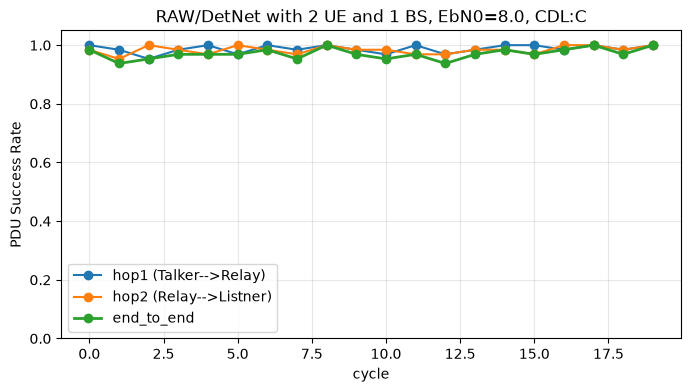

In [7]:
import matplotlib.pyplot as plt

e2e = [r["end_to_end_success_rate"] for r in results]
hop1 = [r["hop1_success_rate"] for r in results]
hop2 = [r["hop2_success_rate"] for r in results]


plt.figure(figsize=(8,4))
plt.plot(hop1, marker="o", label="hop1 (Talker-->Relay)")
plt.plot(hop2, marker="o", label="hop2 (Relay-->Listner)")
plt.plot(e2e, marker="o", label="end_to_end", linewidth=2)
plt.xlabel("cycle")
plt.ylabel("PDU Success Rate")
plt.ylim(0, 1.05)
plt.legend()
plt.title(f"RAW/DetNet with 2 UE and 1 BS, EbN0={EBN0_DB}, CDL:{CDL_MODEL}")
plt.grid(alpha=0.3)
plt.show()


In [8]:
#We can convert the fixed 2 slots DetNet cycle into realistic latency value
#ofdm_symbol_duration = RESOURCE_GRID.ofdm_symbol_duration
#slot_duration = NUM_OFDM_SYMBOLS * ofdm_symbol_duration
#end_to_end_latencys = 2*slot_duration

#print (f"OFDM Symbol Duration with CP: {ofdm_symbol_duration*1e6:.3f} us")
#print (f"Slot Duration: {slot_duration*1e6} us")
#print (f"End_to_End Latency: {end_to_end_latencys*1e6:.3f}us")


#for r in results:
 #   r["end_to_end_latencys"]=end_to_end_latencys


#for cycle, stats in enumerate (results):
 #   print (f"cycle{cycle:2d} | end_to_end: ok:{stats['end_to_end_success_rate']*100:5.1f}%"
 #         f"|latency: {stats['end_to_end_latencys']*1e3:4f}ms"
 #         f"({stats['end_to_end_latency_slots']} slots)")
    

**Step2: Rebundancy--RAW Path Replicatuon and Elimination Mechanism**

-The baseline from step 1 implemented a single path with no protection, if either hop drops the PDU, the transmission failed

-RAW intends to utilize **PAREO (Packet Replicate and Eliminiate)** to replicate the PDU across multiple disjoint paths, then eliminate duplicates at the receiver and accept the PDU if at least one path delivered it correctly.


The topology in step 2 should be:


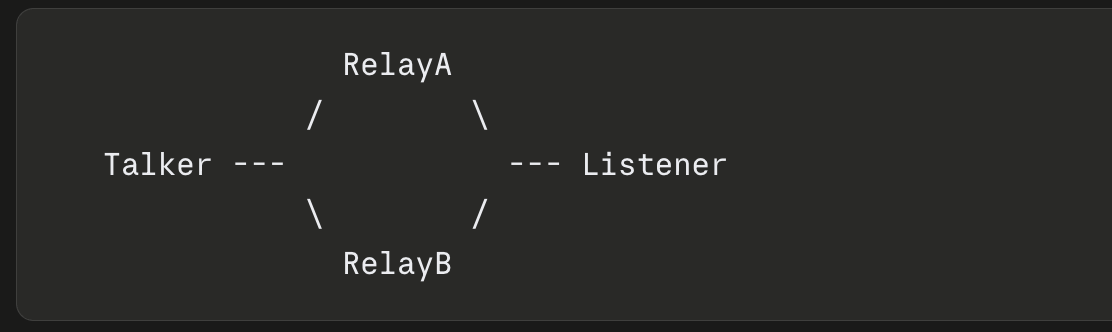


We also need to clearify End_to_End Success is PATH A or Path B, and the resource from Talker remians identical other than adding slots to emphasize the reduancy based on the baseline structure

In [9]:
class RedundantDetNetScheduler:
    """
    The redundancy form RAW is to replicate each PDU over two independent
    paths and remain fixed 2 slots cycle as the baseline has

    Path A: Talker-->Relay A-->Listener
    Path B: Talker-->Relay B--> Listner

    The success delivery is based on EITHER path has PDU arrived
    """

    def __init__(self, batch_size=BATCH_SIZE, ebno=EBN0_DB,clock=None):
        self.batch_size = batch_size


        #Path A
        self.hop1a=PHYLINK("Talker-->RelayA")
        self.hop2a=PHYLINK("RelayA-->Listener")

        #Path B
        self.hop1b=PHYLINK("Talker-->RelayB")
        self.hop2b=PHYLINK("RelayB-->Listener")

        self.clock = clock if clock is not None else SimClock(slot_duration_s)


    def run_cycle(self):

        departure_time=self.clock.now()
        #Slot 0 Talker replicates two PDUs for both relays
        tx_bits, rxA1, okA1 = self.hop1a(self.batch_size)

        _, rxB1, okB1 = self.hop1b(self.batch_size, tx_bits=tx_bits)
        self.clock.advance_slot()
        
      


        #Slot 1 Each relay fowards the received PDU (Store and Foward)
        _, rxA2, okA2 = self.hop2a(self.batch_size, tx_bits=rxA1)
        _, rxB2, okB2 = self.hop2b(self.batch_size, tx_bits=rxB1)

        arrival_time=self.clock.advance_slot()


        path_a_ok = okA1 & okA2
        path_b_ok = okB1 & okB2

        #Elimination: the reciever should only accept the pdu if either path
        end_to_end_ok = path_a_ok | path_b_ok
        latency_s = arrival_time - departure_time

        return {
            "path_a_success_rate": float(np.mean(path_a_ok)),
            "path_b_success_rate": float(np.mean(path_b_ok)),
            "end_to_end_success_rate": float(np.mean(end_to_end_ok)),
            "end_to_end_ok": end_to_end_ok,
            "departure_time_s":departure_time,
            "arriveal_time_s":arrival_time,
            "end_to_end_latency_s":latency_s,
            "end_to_end_latency": round(latency_s/slot_duration_s)
            
        }
        
        
        

Now, we can launch a comparable experiement between baseline and fundamental redundancy model, the seed and number of cycles remain the same

In [10]:
torch.manual_seed (1)

baseline_scheduler = DetNetScheduler(batch_size=BATCH_SIZE)
redundant_scheduler = RedundantDetNetScheduler(batch_size=BATCH_SIZE)

num_cycles = 20
baseline_results = []
redundant_results = []

for cycle in range(num_cycles):
    b_stats = baseline_scheduler.run_cycle()
    r_stats = redundant_scheduler.run_cycle()

    baseline_results.append(b_stats)
    redundant_results.append(r_stats)

    print(f"cycle {cycle:2d} | baseline end to end : {b_stats['end_to_end_success_rate']*100:5.1f}%"
          f"(latency in baseline {b_stats['end_to_end_latency_s']*1e3:.4f} ms)"
          f"| redundant end to end: {r_stats['end_to_end_success_rate']*100:5.1f}%"
          f"(latency with redundancy: {r_stats['end_to_end_latency_s']*1e3:.4f}ms)"
          f"| path A: {r_stats['path_a_success_rate']*100:5.1f}%"
          f"| path B: {r_stats['path_b_success_rate']*100:5.1f}%"
        
        
    )


cycle  0 | baseline end to end :  98.4%(latency in baseline 1.0070 ms)| redundant end to end: 100.0%(latency with redundancy: 1.0070ms)| path A:  95.3%| path B:  93.8%
cycle  1 | baseline end to end : 100.0%(latency in baseline 1.0070 ms)| redundant end to end: 100.0%(latency with redundancy: 1.0070ms)| path A:  93.8%| path B:  96.9%
cycle  2 | baseline end to end :  96.9%(latency in baseline 1.0070 ms)| redundant end to end: 100.0%(latency with redundancy: 1.0070ms)| path A:  95.3%| path B:  98.4%
cycle  3 | baseline end to end : 100.0%(latency in baseline 1.0070 ms)| redundant end to end: 100.0%(latency with redundancy: 1.0070ms)| path A:  90.6%| path B:  96.9%
cycle  4 | baseline end to end :  98.4%(latency in baseline 1.0070 ms)| redundant end to end: 100.0%(latency with redundancy: 1.0070ms)| path A:  96.9%| path B:  96.9%
cycle  5 | baseline end to end :  96.9%(latency in baseline 1.0070 ms)| redundant end to end: 100.0%(latency with redundancy: 1.0070ms)| path A:  98.4%| path B:

We can also plot these results

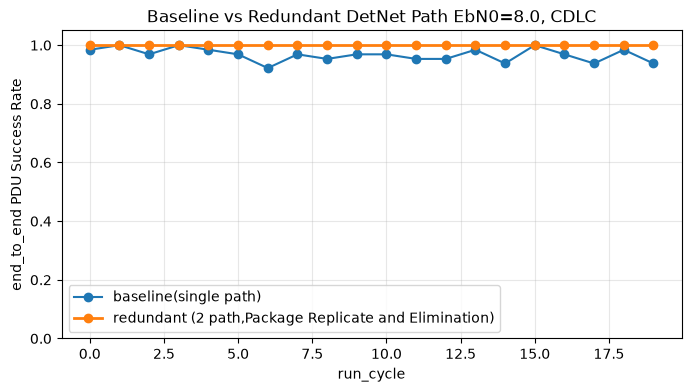

Basline mean end_to_end success:96.72% (PER3.28%)
Redundant mean end_to_end success:100.00% (PER0.00%)
No End to End failure is observed on the redundant path during this simulation


In [11]:
baseline_e2e = [r['end_to_end_success_rate'] for r in baseline_results]
redundant_e2e = [r['end_to_end_success_rate'] for r in redundant_results]

plt.figure(figsize=(8,4))
plt.plot(baseline_e2e, marker="o", label="baseline(single path)")
plt.plot(redundant_e2e, marker="o", label="redundant (2 path,Package Replicate and Elimination)",linewidth=2)
plt.xlabel("run_cycle")
plt.ylabel("end_to_end PDU Success Rate")
plt.ylim(0, 1.05)
plt.legend()
plt.title(f"Baseline vs Redundant DetNet Path EbN0={EBN0_DB}, CDL{CDL_MODEL}")
plt.grid(alpha=0.3)
plt.show()

baseline_mean=np.mean(baseline_e2e)
redundant_mean=np.mean(redundant_e2e)
baseline_per=1-baseline_mean
redundant_per=1-redundant_mean

print(f"Basline mean end_to_end success:{baseline_mean*100:.2f}% (PER{baseline_per*100:.2f}%)")
print(f"Redundant mean end_to_end success:{redundant_mean*100:.2f}% (PER{redundant_per*100:.2f}%)")

if redundant_per >0:
    print(f"PER reduction factor: {baseline_per/redundant_per:.1f}x")
else:
    print (f"No End to End failure is observed on the redundant path during this simulation")

        


Let's compute Maximum Consecutive Loss (MCL) since it is one of the key performance indicator from RAW, we need to have **raw per-PDU boolean outcome** not aboout the per cycle mean success rate. We need to find the longest run of consecutive failure across total cycles, then report the worst one, which the number of a RAW-spec SLA represents, since mean PDR can hide a bad streak.

In [12]:
def Max_Consecutive_Loss(ok_matrix):

    """
    ok_matrix: shape[num_cycles, batch_size], bool. Each column is one
    independent PDU stream observed over num_cycles time step, Returning
    the MCL per stream.
    """

    num_cycles, batch_size = ok_matrix.shape
    mcl_per_stream = np.zeros(batch_size, dtype=int)

    for b in range (batch_size):
        run = 0
        max_run=0
        for c in range (num_cycles):
            if not ok_matrix[c,b]:
                run+=1
                max_run=max(max_run, run)
            else:
                run = 0
        mcl_per_stream[b]=max_run
    return mcl_per_stream


baseline_ok_matrix=np.stack([r["end_to_end_ok"] for r in baseline_results])
redundant_ok_matrix=np.stack([r["end_to_end_ok"] for r in redundant_results])

baseline_mcl=Max_Consecutive_Loss(baseline_ok_matrix)
redundant_mcl=Max_Consecutive_Loss(redundant_ok_matrix)

print(f"Baseline MCL: Worst Stream = {baseline_mcl.max()} consecutive lossess"
     f"(Mean Across Streams: {baseline_mcl.mean():.2f})")

print(f"Reduandant MCL: Worse Stream = {redundant_mcl.max()} conseutive lossses"
     f"(Mean Across Streams: {redundant_mcl.mean():.2f})")

Baseline MCL: Worst Stream = 1 consecutive lossess(Mean Across Streams: 0.52)
Reduandant MCL: Worse Stream = 0 conseutive lossses(Mean Across Streams: 0.00)


Before we develop the next stage, we would like to define a **Services Level Agreement** targetting for this simulation model, and it requires three measurable metrics:

-**Packet Delivery Rate (PDR)**: it represents the PDUs successully delivered end-to-end, this is an *agregate/mean* metric.
-**Latency Boundary (Measured Latency)**:the time difference that a PDU departures and arrives at the encorder side, this is *not a mean metric*, that one single late packet is considered as a fault gardless of mean latency value.
-**Maximum Consecutive Less (MCL)**:the longest tolerable run of end-to-end failures, and it *cannot be considered as a mean* metric.


As for the simulation that we can build in Sionna, initially, we define following targt SLA:


**PDR:≥ 99.9%**
**Latency:≤ 1ms**
**MCL:≤1**

This is modest target we set for the simulation serving for the first paper, it is dynamic and we must upgrade it in the following development stages


**Point of Local Repair**: the next stage, we want to have a control loop that engages the protection path only when it needs, and the trigger factors can be link degradation, and we can have an efficient topology closing to RAW model.

###React within the same cycle

A post-hoc scheme is not suitable for industrial operation since it must implement the core mechanism one full cycle late, the solution is to have a physical proxy that is available before decoding but after that process.

We have added a stored self.last_no_eff section, and we need to implement the new `LinkQualityMonitor` to have a **Point of Local Repair**

The following section is **only the process of constructing `LinkQualityMonitor`, `PLRscheduler`, and a simple simulation recycle**, we will compare these models later on.



In [13]:
class LinkQualityMonitor:
    """
    Tracking the link-quality in real time for mitigation process.
    If high no_eff displays, it represents the low link qualition, and the countermeasure should be engaged
    """

    def __init__(self, alpha=0.5, engage_no_eff=None, disengage_no_eff=None):
        if disengage_no_eff is not None and engage_no_eff is not None and disengage_no_eff >= engage_no_eff:
            raise ValueError("disengage_no_eff must be lower than engage_no_eff because higher no_eff means worse link quality")
        self.alpha = alpha
        self.engage_no_eff=engage_no_eff
        self.disengage_no_eff=disengage_no_eff
        self.ewma_no_eff=None
        self.backup_engaged=False

    def decide (self, current_no_eff):
        """
        Called during the mid-cycle, right after hop1A's channel estimation is available.
        Udpating the EWMA with this cycle's reading and returning the engage decision for the SAME cycyle.
        
        """
        if self.ewma_no_eff is None:
            self.ewma_no_eff = current_no_eff #The initial observation, there is no historical record yet
        else:
            self.ewma_no_eff = self.alpha*current_no_eff+(1-self.alpha)*self.ewma_no_eff
            
        if not self.backup_engaged and current_no_eff >= self.engage_no_eff:
            self.backup_engaged=True
        elif self.backup_engaged and current_no_eff <= self.disengage_no_eff:
            self.backup_engaged=False
        return self.backup_engaged
            

    



**Expotentially Weighted Moving Average** is a mechanism to add wieght to the newest rading get vs the accumlated history, higher `alpha` reacts faster but noiser,
lower `alpha` is smoother but slower to notice the change, this technique aims to stop the occasional packet affecting the decision, the more sophsicated reasons:

`The problem: self.hop1a.last_no_eff is computed from a batch of only 64 PDUs, each seeing its own independent CDL channel draw. Averaging 64 random samples still leaves some sampling noise in the result — cycle to cycle, no_eff will bounce around a bit even if the true underlying channel condition hasn't actually changed. If LinkQualityMonitor compared that raw, noisy number directly against a single threshold every cycle, it could flip backup on and off rapidly just from statistical wobble, not real degradation — wasting the exact resource savings PLR is supposed to deliver.`


###Calibration


We must calibrate the **threshold** firstly because `no_eff` nomral values depend on the EBN0/CDL/Coderate configuration, we run few cycles at normal EBN0 and another few ones with degraded EBN0 to check the variation of *no_eff*  abased on both rigmes, then we need to set `engage_no_eff/disengage_eff` betwen those ranges.

In [14]:
#Calibration:observing no_eff at nominal and degraded EBN0 before selecting the thresholds
probe_link=PHYLINK("calibration probe")

probe_link.ebno_db=EBN0_DB#Nominal
_=probe_link(BATCH_SIZE)
print(f"no_eff at nominal EBN0 ({EBN0_DB} db): {probe_link.last_no_eff:.6f}")

probe_link.ebno_db=EBN0_DB-5.0 #Degradation
_=probe_link(BATCH_SIZE)
print(f"no_eff at degraded EBN0 ({EBN0_DB} db): {probe_link.last_no_eff:.6f}")


print("\nSet engage_no_eff/disengae_no_eff between these two numbers below, "
      "closer to the nominal value for a sensitive trigger, closer to the"
     "degraded value for a conservative one.")


no_eff at nominal EBN0 (8.0 db): 0.620727
no_eff at degraded EBN0 (8.0 db): 15.007045

Set engage_no_eff/disengae_no_eff between these two numbers below, closer to the nominal value for a sensitive trigger, closer to thedegraded value for a conservative one.


In [15]:
def ebno_for_cycle(cycle, nominal_ebno=EBN0_DB, fade_start=8, fade_end=13, fade_penalty=5.0):
    """
    Test hareness: simulating path A with Talker-->Relay A link degrading fro cycles [fade_start, fade_end],
    then recoevering. A realistic system would get this signal from measured link quality not a scripted schedule

    """
    if fade_start<=cycle<=fade_end:
        return nominal_ebno-fade_penalty

    else:
        return nominal_ebno



class PLRScheduler:
    """
    Point of Local Repair: Relay B only transmits when the LinkQualityMonitor
    detects degradation on Relay A within its real-time channel quality (no_eff)
    that affects on decision and action within the same cycle before PDU is decoded
    from Relay A.
    """

    def __init__(self, batch_size=BATCH_SIZE, clock=None, monitor=None):
        self.batch_size=batch_size

        self.hop1a=PHYLINK("Talker-->RelayA")
        self.hop2a=PHYLINK("RelayA-->Listener")
        self.hop1b=PHYLINK("Talker-->RelayB")
        self.hop2b=PHYLINK("RelayB-->Listener")


        self.clock=clock if clock is not None else SimClock(slot_duration_s)
        self.monitor=monitor#Required: passing a calibrated LinkQualityMonitor


    def run_cycle(self, ebno_override=None):
        if ebno_override is not None:
            self.hop1a.ebno_db=ebno_override
            self.hop2a.ebno_db=ebno_override

        departure_time=self.clock.now()

        #Slot 0 part 1: Primary path transmits and its channel is estimated
        tx_bits, rxA1, okA1=self.hop1a(self.batch_size)

        #Real-tim decision for the same cycle, no_eff rading is available now before hop2a decodes
        engage_backup=self.monitor.decide(self.hop1a.last_no_eff)

        #Slot 0 part 2: only transmitted if the monitor engaged backup
        if engage_backup:
            _,rxB1, okB1=self.hop1b(self.batch_size,tx_bits=tx_bits)
        self.clock.advance_slot()


        #Slot 1
        _, rxA2, okA2 = self.hop2a(self.batch_size, tx_bits=rxA1)
        
        if engage_backup:
            _, rxB2, okB2 = self.hop2b(self.batch_size, tx_bits=rxB1) #Redunadncy tirgger

        arrival_time=self.clock.advance_slot()

        path_a_ok=okA1 & okA2

        if engage_backup:
            path_b_ok = okB1 & okB2
            end_to_end_ok = path_a_ok | path_b_ok
            path_b_success_rate=float(np.mean(path_b_ok))
        else:
            end_to_end_ok=path_a_ok
            path_b_success_rate=None
        latency_s=arrival_time-departure_time
        
          

        return {
            "backup_engaged": engage_backup,
            "no_eff": self.hop1a.last_no_eff,
            "path_a_success_rate": float(np.mean(path_a_ok)),
            "path_b_success_rate": path_b_success_rate,
            "end_to_end_success_rate": float(np.mean(end_to_end_ok)),
            "end_to_end_ok": end_to_end_ok,#It should be MCL
            "departure_time_s":departure_time,
            "arrival_time_s": arrival_time,
            "end_to_end_latency_s":latency_s,
            "end_to_end_latency_slots": round(latency_s/slot_duration_s),
        
        }
            
        
        

        
    

In [16]:
torch.manual_seed(1)

#The value here should depend on the calibration cell with its no_eff

monitor=LinkQualityMonitor(alpha=0.5, engage_no_eff=2.5, disengage_no_eff=1.5)
plr_scheduler=PLRScheduler(batch_size=BATCH_SIZE, monitor=monitor)


num_cycles=20
plr_results=[]

for cycle in range (num_cycles):
    ebno_this_cycle=ebno_for_cycle(cycle)
    stats=plr_scheduler.run_cycle(ebno_override=ebno_this_cycle)
    plr_results.append(stats)


    backup_str="ENGAGED" if stats["backup_engaged"] else "idle"
    pB=f"{stats['path_b_success_rate']*100:5.1f}% " if stats["path_b_success_rate"] is not None else "n/a"
    print(f"cycle{cycle:2d} | ebno:{ebno_this_cycle:4.1f} dB |no_eff:{stats['no_eff']:.6f}"
         f" | backup:{backup_str}"
         f" | pathA: {stats['path_a_success_rate']*100:5.1f}% |path B:{pB}"
         f" | end_to_end: {stats['end_to_end_success_rate']*100:5.1f}%"
         f" | latency: {stats['end_to_end_latency_s']*1e3:4f}ms")

    engaged_fraction=np.mean([s['backup_engaged'] for s in plr_results])
    print(f"\n Backup path engaged in {engaged_fraction*100:.1f}% of cycles"
         f"(vs. 100% for always-on redundancy link).")

    

cycle 0 | ebno: 8.0 dB |no_eff:0.627039 | backup:idle | pathA:  98.4% |path B:n/a | end_to_end:  98.4% | latency: 1.007018ms

 Backup path engaged in 0.0% of cycles(vs. 100% for always-on redundancy link).
cycle 1 | ebno: 8.0 dB |no_eff:0.594280 | backup:idle | pathA:  96.9% |path B:n/a | end_to_end:  96.9% | latency: 1.007018ms

 Backup path engaged in 0.0% of cycles(vs. 100% for always-on redundancy link).
cycle 2 | ebno: 8.0 dB |no_eff:0.629200 | backup:idle | pathA:  96.9% |path B:n/a | end_to_end:  96.9% | latency: 1.007018ms

 Backup path engaged in 0.0% of cycles(vs. 100% for always-on redundancy link).
cycle 3 | ebno: 8.0 dB |no_eff:0.622036 | backup:idle | pathA:  98.4% |path B:n/a | end_to_end:  98.4% | latency: 1.007018ms

 Backup path engaged in 0.0% of cycles(vs. 100% for always-on redundancy link).
cycle 4 | ebno: 8.0 dB |no_eff:0.614834 | backup:idle | pathA:  98.4% |path B:n/a | end_to_end:  98.4% | latency: 1.007018ms

 Backup path engaged in 0.0% of cycles(vs. 100% fo

## Plane Separarion

We have a fundamental blueprint at this point, but we must separate two primary planes based on the specifications on RFC8655, RFC9912, and RFC9913

The current `PLRScheduler` mixes two operations with one method whose decision on `backup_engage` and executing PHY transmissions altogether, we must split the decisive and transportation mechanism to match the RAW requirements based on DetNet architecture, yet it is more feasible to scale up the relay and BS nodes in the later stage.

The way of resolving it is to add a `RAWController` class, which should not have `PHYLINK` objects and does not transmit the data, it only needs to map `LinkQuality` reading to an active-path decision. The regression ensures that it reproduces PLRScheduler's own decisions, and utilize `no_eff` value from plr_results without adding new PHY simulation.

In [17]:
class RAWController:
    """
    Control plane: it must justify WHICH path should be active for this cycle
    based on the link quality (no_eff). It should not have PHY objects and does
    not transmit anything.

    """

    def __init__(self, monitors):
        """
        monitors: direct mapping a link to a calibrated LinkQualityMonitor
        that is responsible for that link.
        
        """
        self.monitors=monitors


    def select_paths(self, quality_readings):
        """
        quality_readings: direct mapping to link name--> this cycle's no_eff value
        for whichever links reported one

        return a dictionary of path activation decisions
        """
        decisions={"path_a": True}#The default path should be active initially

        engage_backup=False
        for link_name, reading in quality_readings.items():
            if link_name in self.monitors:
                if self.monitors[link_name].decide(reading):
                    engage_backup=True
                    
        decisions["path_b"]=engage_backup
        return decisions

        

**Regression Inspect**: before anything can utilize RAWController, confirming that it should reproduce `PLRScheduler ` with its engage and disengage exactly, by using the same no_eff values and same calibrated thresholds, stage 2 should not be considered if it does not match.

In [18]:
check_monitor=LinkQualityMonitor(alpha=0.5, engage_no_eff=2.5, disengage_no_eff=1.5)
controller = RAWController(monitors={"hop1a":check_monitor})

mismatches=0
for cycle, stats in enumerate(plr_results):
    decision=controller.select_paths({"hop1a":stats["no_eff"]})
    if decision["path_b"]!= stats["backup_engaged"]:
        mismatch+=1
        print(f"Mismatch happens at cycle: {cycle}: controller={decision['path_b']}, scheduler={stats['backup_engaged']}")
    if mismatches==0:
        print(f"RAWController is producing the same decision as PLRScheduler for all {len(plr_results)} cycles.")
    else:
        print(f"{mistaches} mismatches founded, not good !")

RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same decision as PLRScheduler for all 20 cycles.
RAWController is producing the same deci

## Randomized Faded Scenario Generator

We start utilzing new methodology to produce a more fluctuating channel condition, because `ebno_for_cycle()` is utilzing fixed fade, and we create a function that generates various randomized scenarios, and we can have a more valuable measurement and convincing results

In [19]:
def Generate_Fade_Scenario(rng, nominal_ebno=EBN0_DB, num_cycles=20,
                          fade_duration_range=(3,8), fade_penalty_range=(2.0, 6.0)):

    """
    The fade scenario has been randomized: a random start cycle,
    duration, and severity (dB penalty), we set the range based on
    the calibiration.

    We utilize a caller-supplied numpy generator to have reproducible
    results based on given seed.

    Returning Per-Cycle EBN0 list plus the scenario's paramters
    
    """

    fade_duration=int(rng.integers(fade_duration_range[0], fade_duration_range[1]+1))
    latest_start=max(num_cycles - fade_duration, 1)
    fade_start=int(rng.integers(0, latest_start))
    fade_penalty=float(rng.uniform(fade_penalty_range[0],fade_penalty_range[1]))

    ebno_schedule=[]
    for cycle in range(num_cycles):
        if fade_start <= cycle < fade_start+fade_duration:
            ebno_schedule.append(nominal_ebno-fade_penalty)
        else:
            ebno_schedule.append(nominal_ebno)
    scenario_info={
        "fade_start": fade_start,
        "fade_duration": fade_duration,
        "fade_penalty": fade_penalty,
        
        
    }

    return ebno_schedule, scenario_info

#Function Check: generating a group of scenarios

rng=np.random.default_rng(seed=42)
for trial in range (5):
    schedule, info=Generate_Fade_Scenario(rng)
    print(f"trial {trial}: start (cycle)={info['fade_start']:2d}, "
          f"duration (cycles)={info['fade_duration']}, "
          f"penalty={info['fade_penalty']:.2f} dB"
         )

trial 0: start (cycle)=13, duration (cycles)=3, penalty=3.76 dB
trial 1: start (cycle)=12, duration (cycles)=5, penalty=4.79 dB
trial 2: start (cycle)= 1, duration (cycles)=4, penalty=5.90 dB
trial 3: start (cycle)= 9, duration (cycles)=7, penalty=5.14 dB
trial 4: start (cycle)= 1, duration (cycles)=6, penalty=3.80 dB


## Consistent Configuration Comparison: Baseline, Redundant, and PLR

We have created a section to generate the random fade based on defined range, now we need to ensure all schedulers have the same scenarios, same seed, and same ebno because we want to have a *fair* comparison and measurments.



In [20]:
rng=np.random.default_rng(seed=123)
scenario_ebno, scenario_info=Generate_Fade_Scenario(rng, nominal_ebno=EBN0_DB, num_cycles=20)
print(f"Scenario: fade starts at cycle {scenario_info['fade_start']}, "
     f"duration for={scenario_info['fade_duration']} cycles, "
     f"penality={scenario_info['fade_penalty']:.2f} dB\n")

torch.manual_seed(1)

baseline_scheduler_m=DetNetScheduler(batch_size=BATCH_SIZE)
redundant_scheduler_m=RedundantDetNetScheduler(batch_size=BATCH_SIZE)
plr_monitor_m=LinkQualityMonitor(alpha=0.5, engage_no_eff=1.35, disengage_no_eff=1.10)
plr_scheduler_m=PLRScheduler(batch_size=BATCH_SIZE, monitor=plr_monitor_m)

num_cycles=len(scenario_ebno)
baseline_results_m=[]
redundant_results_m=[]
plr_results_m=[]

for cycle in range(num_cycles):
    ebno_this_cycle=scenario_ebno[cycle]

    #Baseline
    baseline_scheduler_m.hop1.ebno_db=ebno_this_cycle
    baseline_scheduler_m.hop2.ebno_db=ebno_this_cycle
    b_stats=baseline_scheduler_m.run_cycle()
    baseline_results_m.append(b_stats)

    #Always On Redundant
    redundant_scheduler_m.hop1a.ebno_db=ebno_this_cycle
    redundant_scheduler_m.hop2a.ebno_db=ebno_this_cycle
    r_stats=redundant_scheduler_m.run_cycle()
    redundant_results_m.append(r_stats)
    
    
    #Point Local Repair
    p_stats=plr_scheduler_m.run_cycle(ebno_override=ebno_this_cycle)
    plr_results_m.append(p_stats)

    print(f"cycle: {cycle:2d} | ebno: {ebno_this_cycle:4.1f} dB "
         f"| Basline: {b_stats['end_to_end_success_rate']*100:5.1f}% "
         f"| Redundant: {r_stats['end_to_end_success_rate']*100:5.1f}% "
         f"| PLR: {p_stats['end_to_end_success_rate']*100:5.1f}% "
         f"| no_eff: {p_stats['no_eff']:.4f}"
         f"(backup {'ON' if p_stats['backup_engaged'] else 'OFF'})"
         )
    


Scenario: fade starts at cycle 11, duration for=3 cycles, penality=2.22 dB

cycle:  0 | ebno:  8.0 dB | Basline:  96.9% | Redundant: 100.0% | PLR:  96.9% | no_eff: 0.7064(backup OFF)
cycle:  1 | ebno:  8.0 dB | Basline:  96.9% | Redundant: 100.0% | PLR:  96.9% | no_eff: 0.6831(backup OFF)
cycle:  2 | ebno:  8.0 dB | Basline:  98.4% | Redundant: 100.0% | PLR: 100.0% | no_eff: 4.6568(backup ON)
cycle:  3 | ebno:  8.0 dB | Basline: 100.0% | Redundant: 100.0% | PLR:  96.9% | no_eff: 0.6007(backup OFF)
cycle:  4 | ebno:  8.0 dB | Basline:  96.9% | Redundant: 100.0% | PLR:  96.9% | no_eff: 0.6603(backup OFF)
cycle:  5 | ebno:  8.0 dB | Basline:  96.9% | Redundant: 100.0% | PLR:  98.4% | no_eff: 0.6230(backup OFF)
cycle:  6 | ebno:  8.0 dB | Basline:  98.4% | Redundant: 100.0% | PLR:  95.3% | no_eff: 0.8039(backup OFF)
cycle:  7 | ebno:  8.0 dB | Basline:  98.4% | Redundant: 100.0% | PLR:  96.9% | no_eff: 0.6820(backup OFF)
cycle:  8 | ebno:  8.0 dB | Basline:  96.9% | Redundant: 100.0% | PLR

## Plots Optimization

We tried to create the modular SLA plots to have efficient analystic results, and they are reusable functions producing the three figures matching the metrics we have defined before, PDR, End-to-End Latency, and wort case MCL, it can use any number of results  and it is capable of displaying singular or multiple comparsion.

**NOTICE:** the overlay results were run under the same conditions (seed, ebno_for_cycle, scheduler), otherwise it is not a fair comparison. `baseline_results/redundant_results` and `plr_results` does not meet this requirement, we will implement this comparison later.

In [21]:
def Plot_Sla_Metrics(results_dict):

    """
    results_dict: it is a mapping label (baseline or redundant) to its list
    of per-cycle result dictionary. Each dict must have 'end_to_end_success_rate',
    'end_to_end_latency', and 'end_to_end_ok'.

    There are three plots in this function icluding PDR per cycle, latency per cycle,
    and worse-case MCL per sheculer that matches the SLA we read from RFC 9912 and RFC 9913
    
    """

    MARKERS=["o", "s", "^", "v", "D", "P"]
    COLORS=["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple","tab:brown"]

    #Plot1: PDR Per Cycle
    plt.figure(figsize=(8,4))
    all_pdr=[]
    for i, (label, results) in enumerate(results_dict.items()):
        cycles=np.arange(len(results))
        pdr=[r["end_to_end_success_rate"]for r in results]
        all_pdr.extend(pdr)
        plt.plot(cycles,pdr,marker=MARKERS[i % len(MARKERS)],color=COLORS[i % len(COLORS)], label=label)

    pdr_min=min(all_pdr)
    pdr_lower=max(0.0, pdr_min-0.05)
    plt.xlabel("Cycle")
    plt.ylabel("PDR (end-to-end success rate)")
    plt.ylim(pdr_lower, 1.02)
    plt.yticks(np.linspace(pdr_lower, 1.0, 6))
    max_cycles=max(len(results) for results in results_dict.values())
    plt.xticks(np.arange(0, max_cycles, max(1, max_cycles //20)))
    plt.legend()
    plt.title("PDR per Cycle")
    plt.grid(alpha=0.3)
    plt.show()


    #Plot2: End-to-End Latency Per Cycle
    
    plt.figure(figsize=(8,4))
    all_latency_us=[]
    for i, (label, results) in enumerate(results_dict.items()):
        cycles=np.arange(len(results))
        latency_s=[r["end_to_end_latency_s"]*1e3 for r in results]
        all_latency_us.extend(latency_s)
        plt.plot(cycles,latency_s, marker=MARKERS[i % len(MARKERS)],color=COLORS[i % len(COLORS)],label=label)
      


    latency_min=min(all_latency_us)
    latency_max=max(all_latency_us)
    latency_pad=max((latency_max-latency_min)*0.15,0.05)
    
    plt.xlabel("Cycle")
    plt.ylabel("End-to-End Latency with ms")
    plt.ylim(latency_min-latency_pad, latency_max+latency_pad)
    plt.xticks(np.arange(0, max_cycles, max(1, max_cycles // 20)))
    plt.legend()
    plt.title("Latency per Cycle")
    plt.grid(alpha=0.3)
    plt.show()


    #Plot3: Worse-Case MCL per Scheduler
    plt.figure(figsize=(8,4))
    labels=[]
    worst_mcl=[]
    for i, (label, results) in enumerate(results_dict.items()):
        ok_matrix=np.stack([r["end_to_end_ok"]for r in results])
        mcl=Max_Consecutive_Loss(ok_matrix)
        labels.append(label)
        worst_mcl.append(mcl.max())
    bar_colors=[COLORS[i % len(COLORS)] for i in range(len(labels))]
    mcl_top=max(worst_mcl)+1
    plt.ylim(0,mcl_top+1)
    plt.yticks(np.arange(0, mcl_top+1, 1))
    plt.bar(labels, worst_mcl,color=bar_colors)
    plt.ylabel("Worst-case MCL (Consecutive Loss)")
    plt.title("MCL per Scheduler")
    plt.grid(alpha=0.3, axis="y")
    plt.show()
    

## Example

Plotting `plr_results` alone

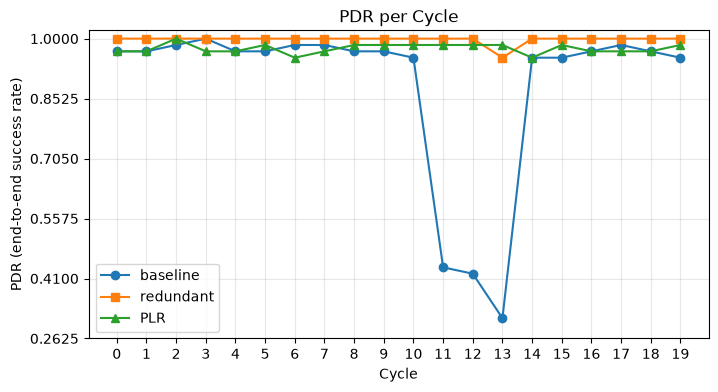

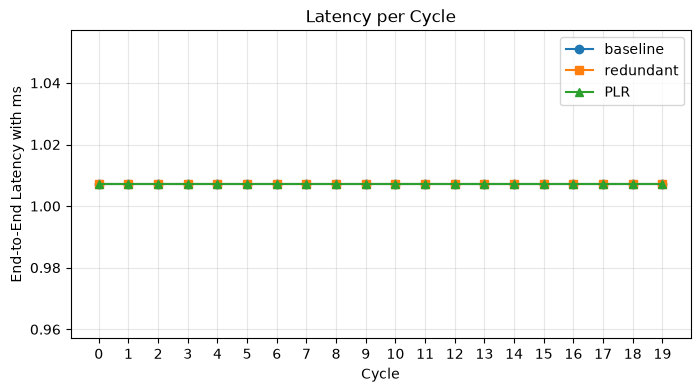

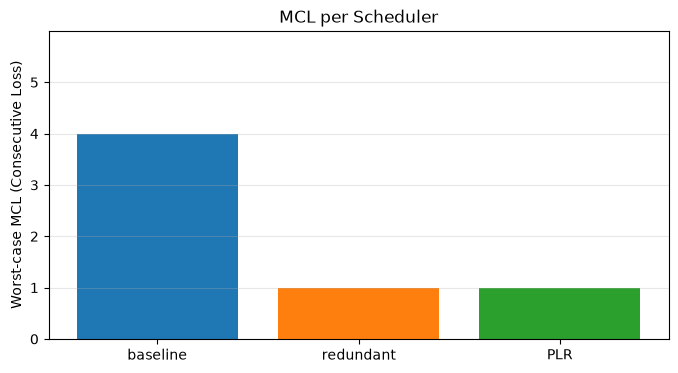

In [22]:


Plot_Sla_Metrics({
    "baseline":baseline_results_m,
    "redundant":redundant_results_m,
    "PLR":plr_results_m
})